# `soma.beams` quickstart

Simulate a beam, decompose it into azimuthal modes, and check the answer
against a closed form. Four short steps; every number below is compared with
something derived independently.

The decomposition is a single call. It FFTs the stamp, removes the linear
phase that puts the beam at the origin, resamples each Fourier ring at uniform
azimuth $\psi$, and FFTs each ring:

$$B(\ell, \psi) = \sum_m b_m(\ell)\, e^{im\psi}$$

$b_0$ is the usual transfer function, $b_2$ the ellipticity, $b_4$ the
hexadecapole. Uniform-$\psi$ resampling is what keeps a circular beam's
spurious $m=4$ near $10^{-10}$; averaging Fourier pixels on annuli instead
inherits the square grid's four-fold sampling symmetry and leaks
$10^{-3}$–$10^{-2}$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from soma import beams

# fixed categorical order, validated for colour-vision deficiency
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300"]
SHAPE, PIX = (512, 512), 0.25  # stamp size and arcmin per pixel, as the real stacks
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
    }
)

## 1. Simulate

An elliptical Gaussian on a 512² stamp at 0.25′ pixels — the stamp size sets
the $\ell$ resolution, so a wide field is worth more here than fine pixels.
`simulate_beam` returns
a pixell enmap on a conventional TAN geometry, so a simulated beam goes through
exactly the same entry points as a real planet stack.

ndmap (512, 512), cdelt = [-0.00416667  0.00416667] deg


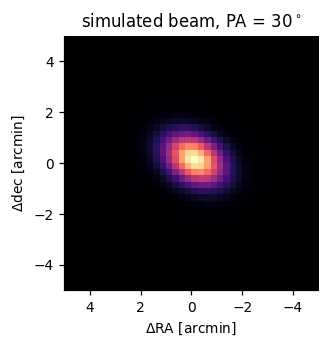

In [2]:
FWHM_MAJ, FWHM_MIN, PA = 2.0, 1.4, 30.0  # arcmin, arcmin, degrees

b = beams.simulate_beam(SHAPE, PIX, FWHM_MAJ, FWHM_MIN, angle_deg=PA)
print(f"{type(b).__name__} {b.shape}, cdelt = {b.wcs.wcs.cdelt} deg")

c, w = 256, 20  # a 20-pixel (5') half-width cutout around the centre
fig, ax = plt.subplots(figsize=(3.0, 3.0))
half = w * PIX  # arcmin
ax.imshow(
    b[c - w : c + w, c - w : c + w], origin="lower", cmap="magma", extent=[half, -half, -half, half]
)  # +RA to the left: cdelt1 < 0
ax.set(
    xlabel="$\\Delta$RA [arcmin]",
    ylabel="$\\Delta$dec [arcmin]",
    title=f"simulated beam, PA = {PA:.0f}$^\\circ$",
)
ax.grid(False)
plt.show()

## 2. Decompose

`beam_modes` is the whole API. Its defaults are built for measured beams: it
fits an elliptical Gaussian, recenters on **that** centre rather than the
first-moment centroid (a filtering bowl drags the centroid off the beam, which
forges an $m=1$ growing like $\ell d/2$), applies an aperture, and reports an
empirical noise floor beside the modes.

In [3]:
ell = np.linspace(200.0, 9000.0, 120)
res = beams.beam_modes(b, ell=ell, mmax=6)

f = res["fit"]
print(
    f"fitted   {f['fwhm_major_arcmin']:.4f}' x {f['fwhm_minor_arcmin']:.4f}'"
    f"  PA {f['angle_deg']:+.3f} deg     (truth {FWHM_MAJ}' x {FWHM_MIN}', {PA})"
)
print(f"centre   {res['center']}   aperture {res['rmax_arcmin']:.1f}'")
print(f"usable   b_0 stays above 2% of b_0(0) out to ell = {res['lmax']:.0f}")

i = np.argmin(abs(ell - 6000))
print(
    f"\nat ell = {ell[i]:.0f}:  rho_2 = {res['rho'][2][i]:.5f}"
    f"   rho_4 = {res['rho'][4][i]:.5f}   floor = {res['floor'][i]:.1e}"
)
print(
    f"m=2 axis {res['orient'][2][i]:.3f} deg  (harmonic.mode_orientation undoes the "
    f"quarter turn; raw arg(b_2) would read {PA + 90:.0f})"
)

fitted   2.0000' x 1.4000'  PA +30.000 deg     (truth 2.0' x 1.4', 30.0)
centre   (256.0, 256.0)   aperture 64.0'
usable   b_0 stays above 2% of b_0(0) out to ell = 9000

at ell = 5968:  rho_2 = 0.13728   rho_4 = 0.00948   floor = 2.2e-04
m=2 axis 30.000 deg  (harmonic.mode_orientation undoes the quarter turn; raw arg(b_2) would read 120)


An ellipse has a closed form on every Fourier ring:
$B \propto \exp[a\cos 2(\psi-\psi_0)]$ with $a = \ell^2(\sigma_{\rm maj}^2 -
\sigma_{\rm min}^2)/4$, so the azimuthal spectrum is the Bessel ladder
$\rho_{2k} = I_k(a)/I_0(a)$ and every odd $m$ vanishes — an ellipse is
inversion-symmetric.

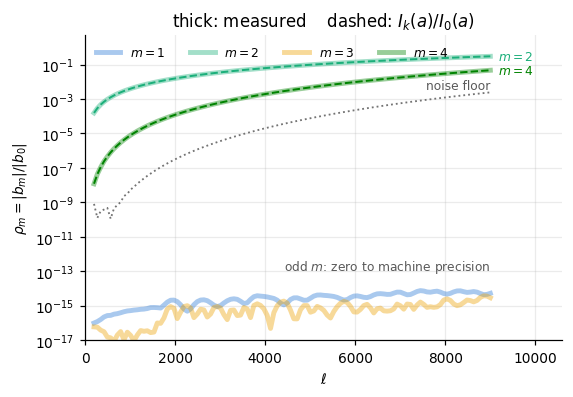

rho_2 vs closed form: max relative error 3.4e-06
rho_4 vs closed form: max relative error 3.0e-06
odd m (must vanish):   2.7e-15, 6.4e-16


In [4]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
for j, m in enumerate((1, 2, 3, 4)):
    # measured drawn thick and translucent so the analytic curve, which lands
    # on top of it to ~3e-6, stays visible inside it rather than under it
    ax.plot(ell, res["rho"][m], color=C[j], lw=3.2, alpha=0.4, label=f"$m={m}$")
    if m % 2 == 0:  # the analytic Bessel ladder, for even m only
        ax.plot(
            ell, beams.elliptical_rho(ell, FWHM_MAJ, FWHM_MIN, k=m // 2), "--", color=C[j], lw=1.3
        )
ax.plot(ell, res["floor"], color="0.45", lw=1.2, ls=":")
ax.annotate(
    "noise floor", (ell[-1], res["floor"][-1]), color="0.35", fontsize=8, ha="right", va="bottom"
)
for j, m in ((1, 2), (3, 4)):  # direct labels on the two modes that are there
    ax.annotate(
        f"$m={m}$",
        (ell[-1], res["rho"][m][-1]),
        color=C[j],
        fontsize=8,
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
    )
ax.annotate(
    "odd $m$: zero to machine precision",
    (ell[-1], 6e-14),
    color="0.35",
    fontsize=8,
    ha="right",
    va="bottom",
)
ax.set(
    yscale="log",
    ylim=(1e-17, 5.0),
    xlim=(0, 10600),
    xlabel=r"$\ell$",
    ylabel=r"$\rho_m = |b_m| / |b_0|$",
    title="thick: measured    dashed: $I_k(a)/I_0(a)$",
)
ax.legend(ncols=4, loc="upper left", fontsize=8)
plt.show()

for m in (2, 4):
    truth = beams.elliptical_rho(ell, FWHM_MAJ, FWHM_MIN, k=m // 2)
    ok = truth > 1e-4
    err = np.nanmax(np.abs(res["rho"][m][ok] / truth[ok] - 1))
    print(f"rho_{m} vs closed form: max relative error {err:.1e}")
print(
    f"odd m (must vanish):   {np.nanmedian(res['rho'][1]):.1e}, {np.nanmedian(res['rho'][3]):.1e}"
)

## 3. Inject a multipole you choose

The sharper test is to dial in a harmonic and demand it back. `moments` adds

$$1 + \sum_m \varepsilon_m \left(\frac{r}{\sqrt2\,\sigma}\right)^{m}
\cos m(\theta - \phi_m)$$

to a circular envelope. The radial weight $r^m$ keeps each term smooth at the
origin and makes the transform closed-form, giving the pure power law
$\rho_m = (\varepsilon_m/2)(\sigma\ell/\sqrt2)^m$.

In [5]:
inject = {3: 0.04, 4: 0.02}
bi = beams.simulate_beam(SHAPE, PIX, 1.7, moments=inject)
# about the construction centre: that is the point the closed form describes,
# and an odd moment displaces the beam, so a fit would absorb part of it
ri = beams.beam_modes(bi, ell=ell, mmax=6, center=(256, 256))

for m, eps in inject.items():
    truth = beams.multipole_rho(ell, 1.7, m, eps)
    ok = (truth > 1e-4) & (truth < 0.5)
    err = np.nanmax(np.abs(ri["rho"][m][ok] / truth[ok] - 1))
    print(f"injected eps_{m} = {eps}:  recovered to {err:.1e} relative")

injected eps_3 = 0.04:  recovered to 3.6e-07 relative
injected eps_4 = 0.02:  recovered to 4.2e-06 relative


## 4. Polarized beams: T→E/B leakage

A `(3, Ny, Nx)` T/Q/U stack goes through the same call. The three components
share one recentering phase, the E/B rotation is applied on each uniform-$\psi$
ring, and `b_m` comes back as (T, E, B) with the leakage beams alongside:

$$\gamma_{E,B}(\ell) = b^{E,B}_0(\ell) \,/\, b^T_0(\ell)$$

Both are ratios of azimuthal *monopoles*, so they are unchanged by any rotation
of the stamp — which is what makes them safe on mixed-frame stacks (scan-locked
T, sky-frame Q/U) and makes them the leakage a power spectrum needs.

b_m shape (3, 7, 120)  = (T/E/B, m, ell)


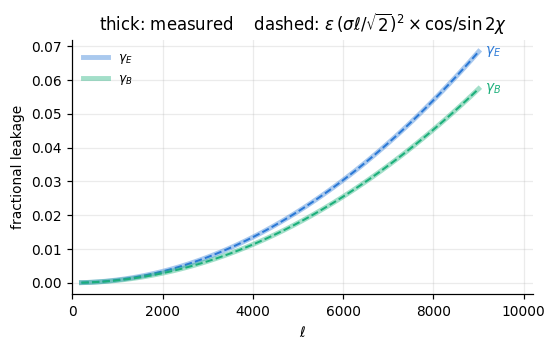

gamma_E: max relative error 6.6e-06   |imaginary part| < 3e-18
gamma_B: max relative error 6.6e-06   |imaginary part| < 2e-18


In [6]:
EPS, CHI = 0.05, 20.0  # chi = 0 is pure E-leakage, 45 deg pure B
p = beams.simulate_pol_beam(SHAPE, PIX, 1.7, eps=EPS, chi_deg=CHI)
rp = beams.beam_modes(p, ell=ell)
print(f"b_m shape {rp['b_m'].shape}  = (T/E/B, m, ell)")

thE, thB = beams.polarized_leakage_rho(ell, 1.7, EPS, CHI)
fig, ax = plt.subplots(figsize=(5.4, 3.0))
for j, (lab, got, want) in enumerate(
    ((r"$\gamma_E$", rp["gamma_E"].real, thE), (r"$\gamma_B$", rp["gamma_B"].real, thB))
):
    ax.plot(ell, got, color=C[j], lw=3.2, alpha=0.4, label=lab)
    ax.plot(ell, want, "--", color=C[j], lw=1.3)
    ax.annotate(
        lab,
        (ell[-1], got[-1]),
        color=C[j],
        fontsize=9,
        ha="left",
        va="center",
        xytext=(4, 0),
        textcoords="offset points",
    )
ax.set(
    xlabel=r"$\ell$",
    ylabel="fractional leakage",
    xlim=(0, 10200),
    title=r"thick: measured    dashed: "
    r"$\varepsilon\,(\sigma\ell/\sqrt{2})^2 \times \cos/\sin 2\chi$",
)
ax.legend(fontsize=8, loc="upper left")
plt.show()

for lab, got, want in (("E", rp["gamma_E"].real, thE), ("B", rp["gamma_B"].real, thB)):
    ok = np.abs(want) > 1e-6
    print(
        f"gamma_{lab}: max relative error {np.nanmax(np.abs(got[ok] / want[ok] - 1)):.1e}"
        f"   |imaginary part| < {np.nanmax(np.abs(rp['gamma_' + lab].imag)):.0e}"
    )

## Where to go next

- `soma.harmonic` holds the estimator itself: `azimuthal_modes` runs it on
  any flat-sky image, with `mode_metrics`, `mode_orientation`, `mode_floor`
  and `l_nyquist` alongside. `beam_modes` is the beam-flavoured wrapper --
  the Gaussian fit, the aperture, the noise floor and the leakage beams.
- The full test suite in `tests/test_beams.py` is itself a worked catalogue of
  what each closed form predicts.